## Health Risk Prediction 

* unterstand the data parttern
* data cleaning
* outier treatment
* handle missing values
* model training
* choose the best model

In [ ]:
# import all important library

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import warnings 
warnings.filterwarnings('ignore')

: 

## Load the dataset

In [2]:
df = pd.read_csv('../data/heart_disease.csv')

In [3]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


## Dataset INformation - 

* Age - Age of the pesent
* Gender - Gender of pesent it is male or female
* Blood Pressure - blood pressure of pesent
* cholesterol Level - Cholesterol level
* Exercise Habits - It explains pesent do exercise low / medium / high
* Smoking - the pesent is smoker or not
* Familt heart Disease - other family member has heart disease or not
* Diabetes - present diabetic of not
* BMI - Body Mass Index, measure of body fat based on height and weight
* High Blood Pressure - indicates whether the person has high blood pressure or not
* Low HDL Cholesterol - shows if good cholesterol level is low (risk factor for heart disease)
* High LDL Cholesterol - indicates high bad cholesterol which can block arteries
* Alcohol Consumption - amount of alcohol intake by the person in high median low 
* Stress Level - level of stress experienced (low / medium / high)
* Sleep Hours - number of hours the person sleeps daily
* Sugar Consumption - amount of sugar intake in diet
* Triglyceride Level - level of fat in blood, higher value increases heart risk
* Fasting Blood Sugar - blood sugar level after fasting (used to detect diabetes)
* CRP Level - C-reactive protein level, shows inflammation in body
* Homocysteine Level - amino acid level in blood, high value can damage blood vessels
* Heart Disease Status - target variable, shows whether person has heart disease or not

In [4]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [6]:
df['Stress Level']

0       Medium
1         High
2          Low
3         High
4         High
         ...  
9995      High
9996      High
9997       Low
9998      High
9999    Medium
Name: Stress Level, Length: 10000, dtype: str

In [7]:
df.describe()

,Age,Blood Pressure,Cholesterol Level,BMI,Sleep Hours,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level
count,9971.000000,9981.000000,9970.000000,9978.000000,9975.000000,9974.000000,9978.000000,9974.000000,9980.000000
mean,49.296259,149.757740,225.425577,29.077269,6.991329,250.734409,120.142213,7.472201,12.456271
std,18.193970,17.572969,43.575809,6.307098,1.753195,87.067226,23.584011,4.340248,4.323426
min,18.000000,120.000000,150.000000,18.002837,4.000605,100.000000,80.000000,0.003647,5.000236
25%,34.000000,134.000000,187.000000,23.658075,5.449866,176.000000,99.000000,3.674126,8.723334
50%,49.000000,150.000000,226.000000,29.079492,7.003252,250.000000,120.000000,7.472164,12.409395
75%,65.000000,165.000000,263.000000,34.520015,8.531577,326.000000,141.000000,11.255592,16.140564
max,80.000000,180.000000,300.000000,39.996954,9.999952,400.000000,160.000000,14.997087,19.999037


## Age colume 

we can see ther minimum age is 18 that means no child present in the dataset

In [8]:
# check null values in dataset
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

## Null valuse present in dataset
All the columns has null value while the maximum null value is in Alcohol Consumption has 2586 null values

In [9]:
df.duplicated().sum()

np.int64(0)

no duplicate column present in dataset

In [10]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


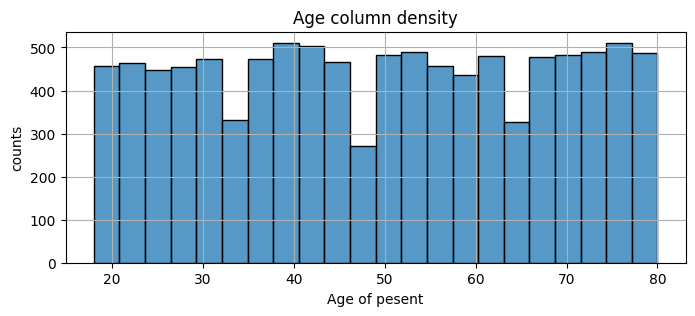

In [11]:
# Age column density

plt.figure(figsize=(8 , 3))
sns.histplot(df['Age'])
plt.title('Age column density')
plt.ylabel('counts')
plt.xlabel('Age of pesent')
plt.grid()
plt.show()

In [12]:
# value count of Gender column

df['Gender'].value_counts()

Gender
Male      5003
Female    4978
Name: count, dtype: int64

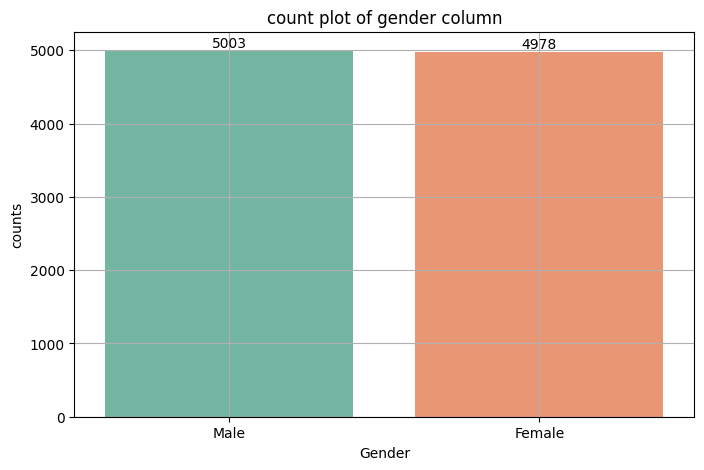

In [13]:
# count of Gender column

plt.figure(figsize=(8 , 5))
sns.countplot(x = df['Gender'] , palette='Set2')
plt.title('count plot of gender column')
plt.ylabel('counts')
plt.xlabel('Gender')
plt.grid()

for i , v in enumerate(df['Gender'].value_counts()):
    plt.text(i , v , str(v) , ha='center' , va='bottom')

plt.show()

In [14]:
# value count of smoker

df['Smoking'].value_counts()

Smoking
Yes    5123
No     4852
Name: count, dtype: int64

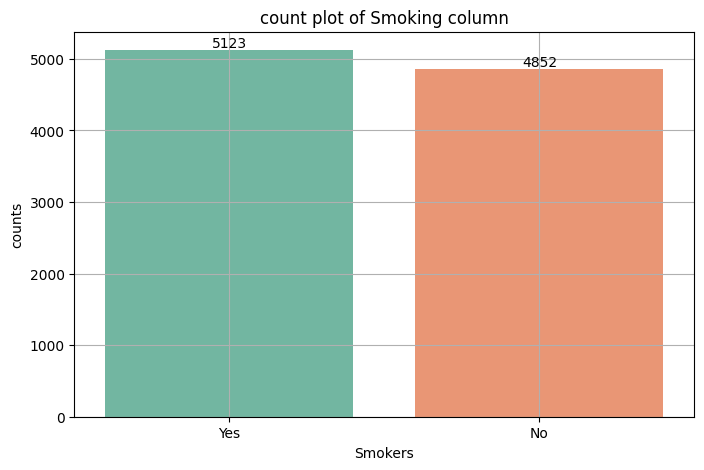

In [15]:
plt.figure(figsize=(8 , 5))
sns.countplot(x = df['Smoking'] , palette='Set2')
plt.title('count plot of Smoking column')
plt.ylabel('counts')
plt.xlabel('Smokers')
plt.grid()

for i , v in enumerate(df['Smoking'].value_counts()):
    plt.text(i , v , str(v) , ha='center' , va='bottom')

plt.show()

## smoker with gender

In [16]:
svg = df.groupby('Gender')['Smoking'].value_counts()
svg = svg.unstack()

<Figure size 800x400 with 0 Axes>

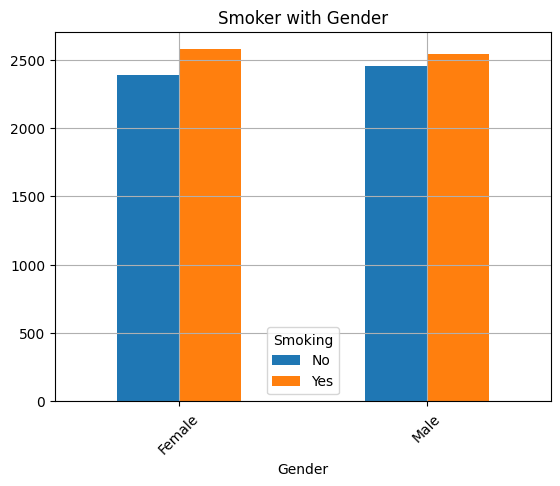

In [17]:
plt.figure(figsize=(8 , 4))
svg.plot(kind='bar')
plt.title('Smoker with Gender')
plt.grid()
plt.xticks(rotation=45)
plt.show()

insight - clearly see count of female smoker is greater then male smoker and both male and female has high no. of smoker than not smoker

In [18]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


## smoking vs Family Heart Disease	

In [19]:
svd = df.groupby('Family Heart Disease')['Smoking'].value_counts()
svd # svd = smoking vs disease

Family Heart Disease  Smoking
No                    Yes        2558
                      No         2432
Yes                   Yes        2553
                      No         2411
Name: count, dtype: int64

<Figure size 800x400 with 0 Axes>

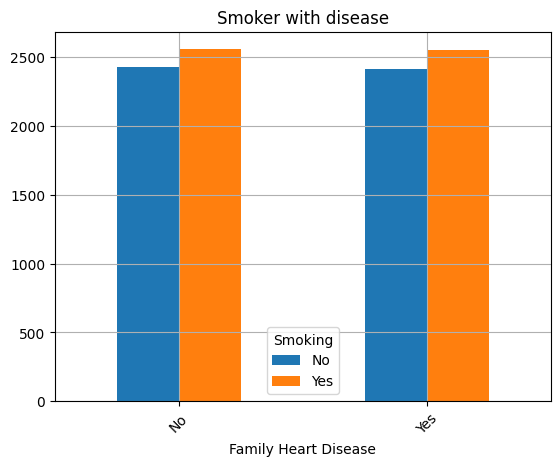

In [20]:
svd = svd.unstack()
plt.figure(figsize=(8 , 4))
svd.plot(kind='bar')
plt.title('Smoker with disease')
plt.grid()
plt.xticks(rotation=45)
plt.show()

## Gender vs Family Heart Disease vs Smoking

In [21]:
svgvd = df.groupby(['Gender' , 'Family Heart Disease'])['Smoking'].value_counts()
svgvd

Gender  Family Heart Disease  Smoking
Female  No                    Yes        1283
                              No         1198
        Yes                   Yes        1289
                              No         1185
Male    No                    Yes        1272
                              No         1228
        Yes                   Yes        1257
                              No         1223
Name: count, dtype: int64

<Figure size 800x400 with 0 Axes>

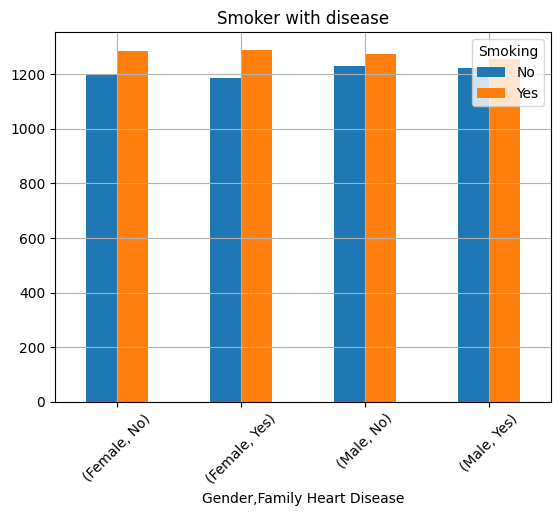

In [22]:
svgvd = svgvd.unstack()
plt.figure(figsize=(8 , 4))
svgvd.plot(kind='bar')
plt.title('Smoker with disease')
plt.grid()
plt.xticks(rotation=45)
plt.show()

here smoker has high chace to heart disease

## Diabetes	

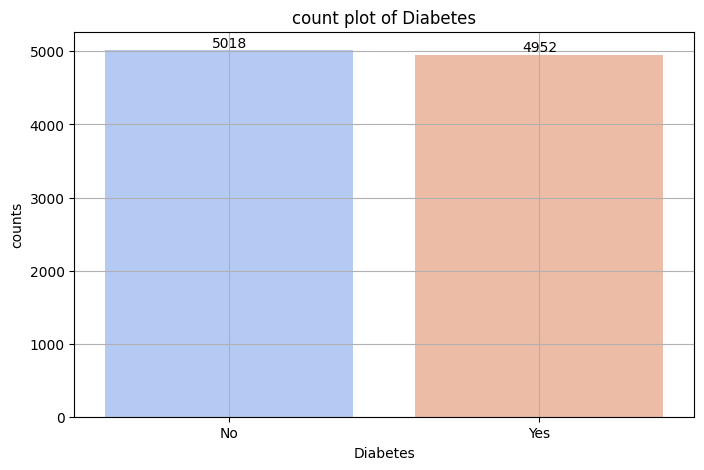

In [23]:
# count plot of diabetes

plt.figure(figsize=(8 , 5))
sns.countplot(x = df['Diabetes'] , palette='coolwarm')
plt.title('count plot of Diabetes')
plt.ylabel('counts')
plt.xlabel('Diabetes')
plt.grid()

for i , v in enumerate(df['Diabetes'].value_counts()):
    plt.text(i , v , str(v) , ha='center' , va='bottom')

plt.show()

In [24]:
# gender with diabetes 

gvd = df.groupby('Diabetes')['Gender'].value_counts()
gvd

Diabetes  Gender
No        Female    2512
          Male      2496
Yes       Male      2489
          Female    2454
Name: count, dtype: int64

<Figure size 800x400 with 0 Axes>

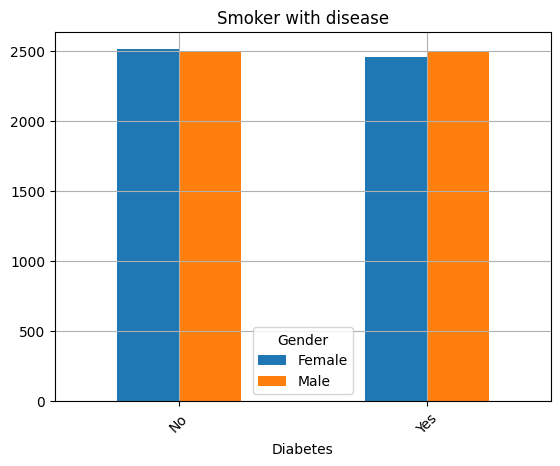

In [25]:
gvd = gvd.unstack()
plt.figure(figsize=(8 , 4))
gvd.plot(kind='bar')
plt.title('Smoker with disease')
plt.grid()
plt.xticks(rotation=45)
plt.show()

count of diabetes male is more then female

In [26]:
# smoker with diabetes

svd = df.groupby('Diabetes')['Smoking'].value_counts()
svd

Diabetes  Smoking
No        Yes        2602
          No         2405
Yes       Yes        2504
          No         2434
Name: count, dtype: int64

<Figure size 800x400 with 0 Axes>

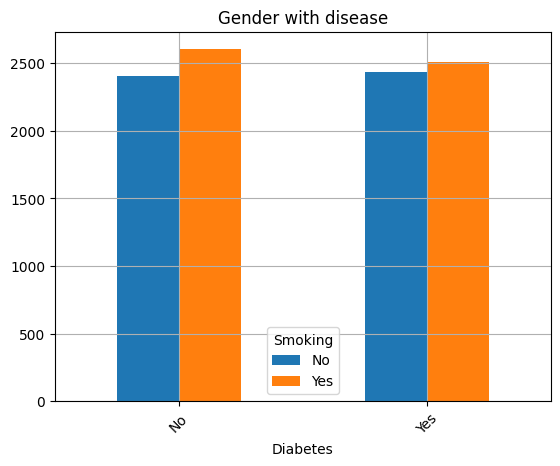

In [27]:
svd = svd.unstack()
plt.figure(figsize=(8 , 4))
svd.plot(kind='bar')
plt.title('Gender with disease')
plt.grid()
plt.xticks(rotation=45)
plt.show()

In [28]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [29]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')

In [30]:
# count plot function

def count_plot(column):
    
    plt.figure(figsize=(8 , 5))
    sns.countplot(x = df[column] , palette='coolwarm')
    plt.title(f"counts of {column}")
    plt.xlabel(column)
    plt.grid()

    for i , j in enumerate(df[column].value_counts()):
        plt.text(i , j , str(j) , ha='center' , va='bottom')
    plt.xticks(rotation = 45)
    plt.show()

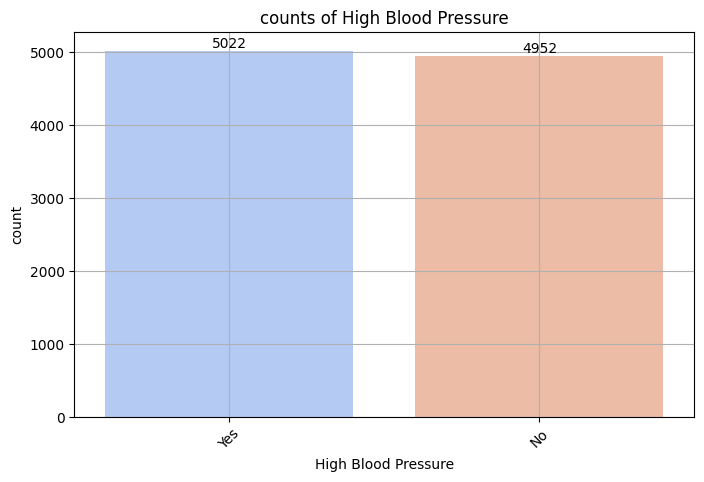

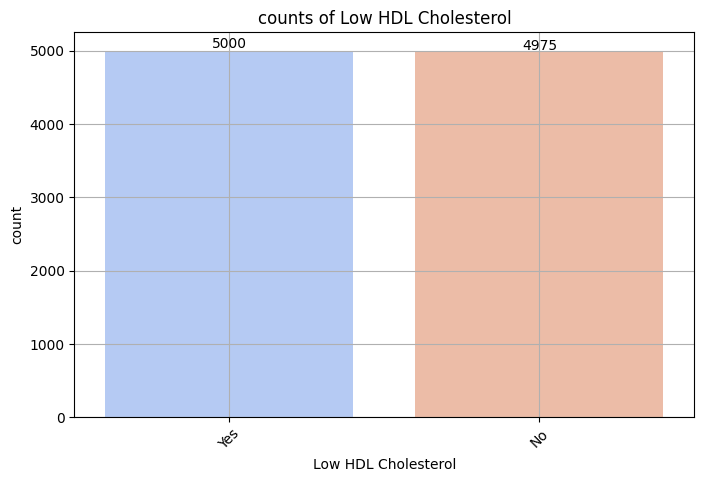

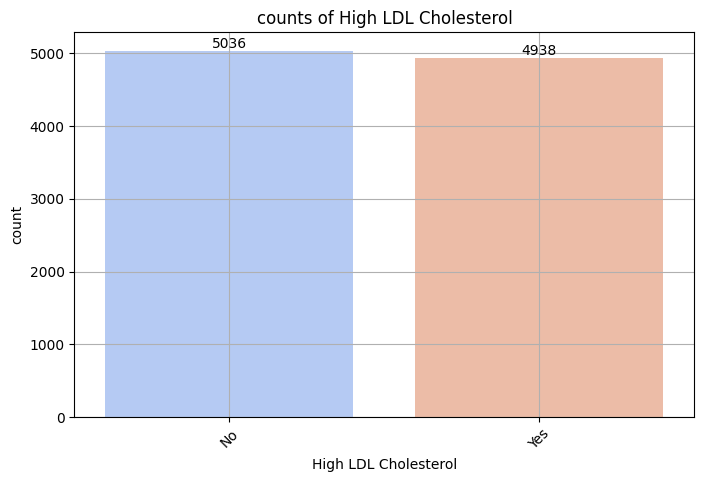

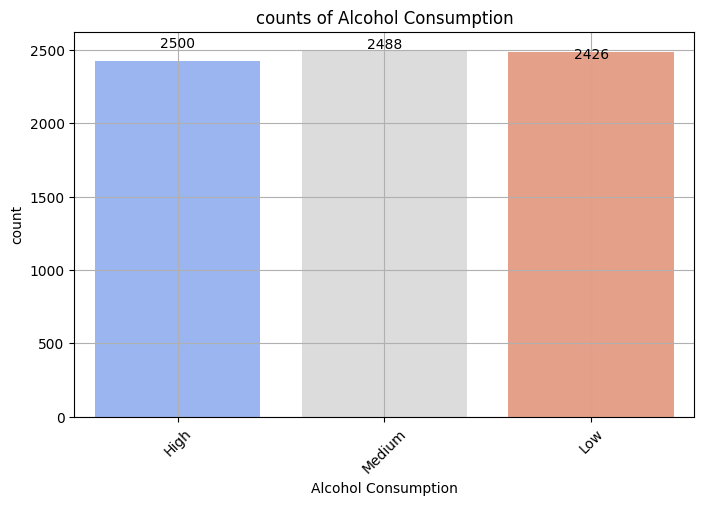

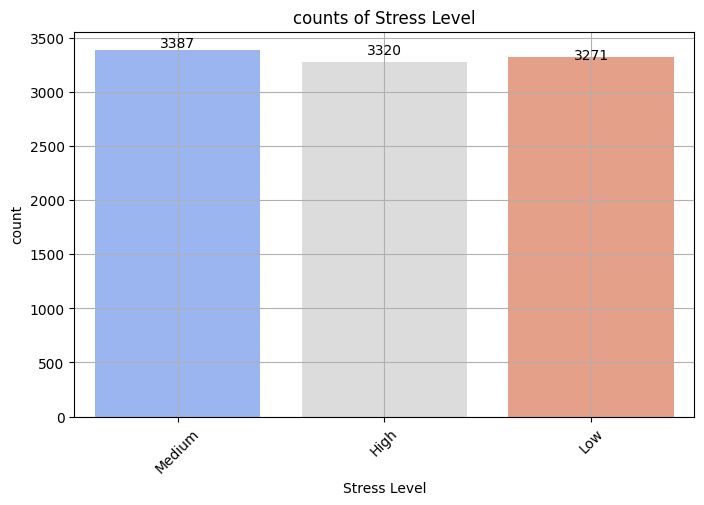

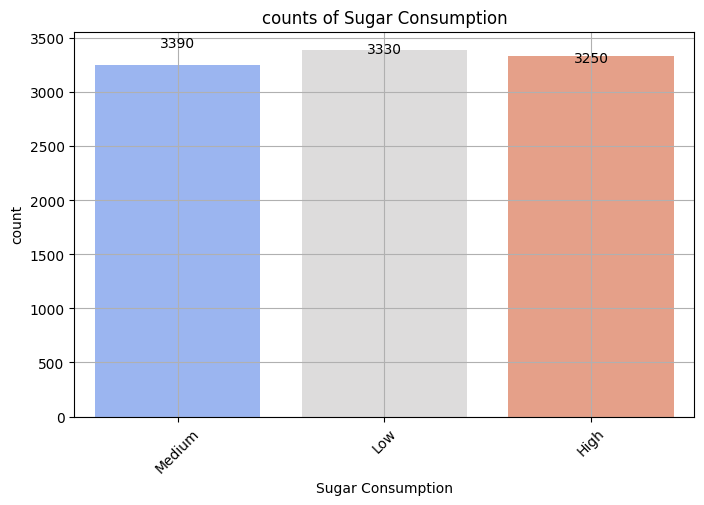

In [31]:
count = ['High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level','Sugar Consumption']

for i in count:
    count_plot(i)

In [32]:
# all above plot with gender

def bar_plot(column):
    
    data = df.groupby('Gender')[column].value_counts()
    data = data.unstack()

    plt.figure(figsize=(8 , 5))
    data.plot(kind = 'bar')
    plt.title(f"{i} with gender")
    plt.xlabel(i)
    plt.grid()
    plt.xticks(rotation=45)
    plt.show()

<Figure size 800x500 with 0 Axes>

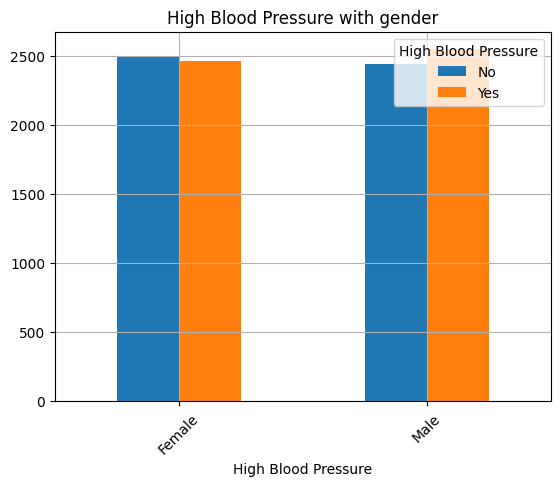

<Figure size 800x500 with 0 Axes>

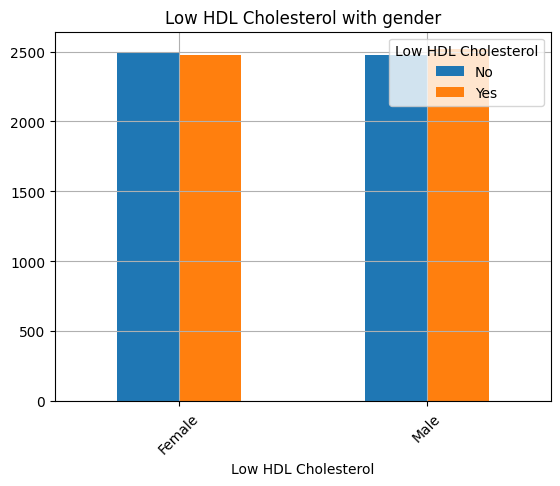

<Figure size 800x500 with 0 Axes>

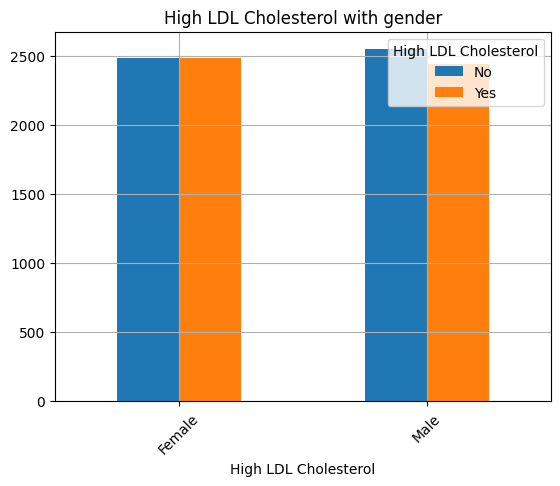

<Figure size 800x500 with 0 Axes>

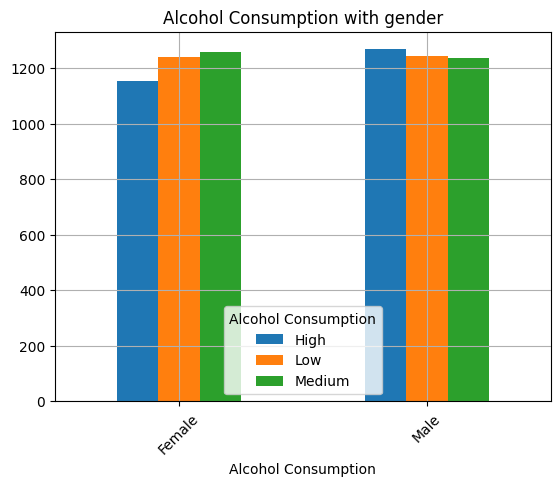

<Figure size 800x500 with 0 Axes>

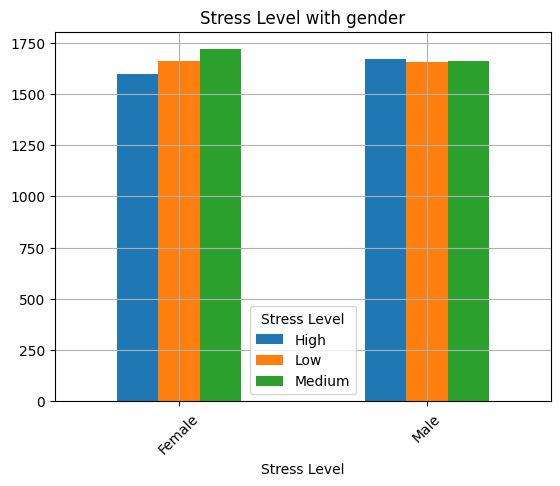

<Figure size 800x500 with 0 Axes>

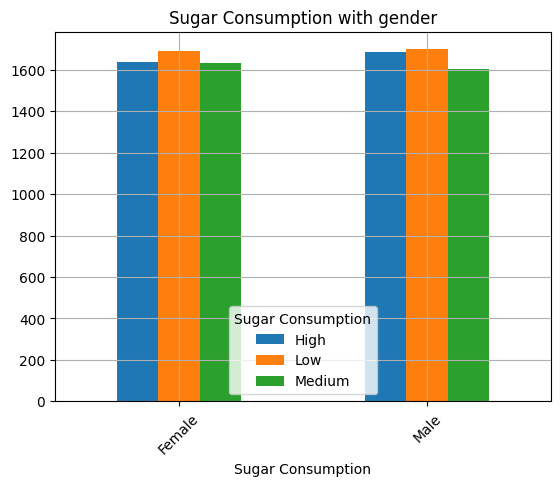

In [33]:
for i in count:
    bar_plot(i)

from above plot

# High Blood Pressure-
* male - male blood pressure is more then female
* most female has no blood pressure while low blood pressure as compare to male 

# Low HDL Cholesterol - 
* more female with low cholesterol level

# High LDL Cholesterol -
* count of high cholestrol is greater than female

# Alcohol Consumption -
* male - most of the male consume high level of alcohol
* female - most of the female consume medium level of alcohol 

# Stress Level -
* male - ligh level stress with male 
* female  - medium level of stress

# Sugar Consumption -
* male - suger consume by male is high
* female - as compare to male low

In [34]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')

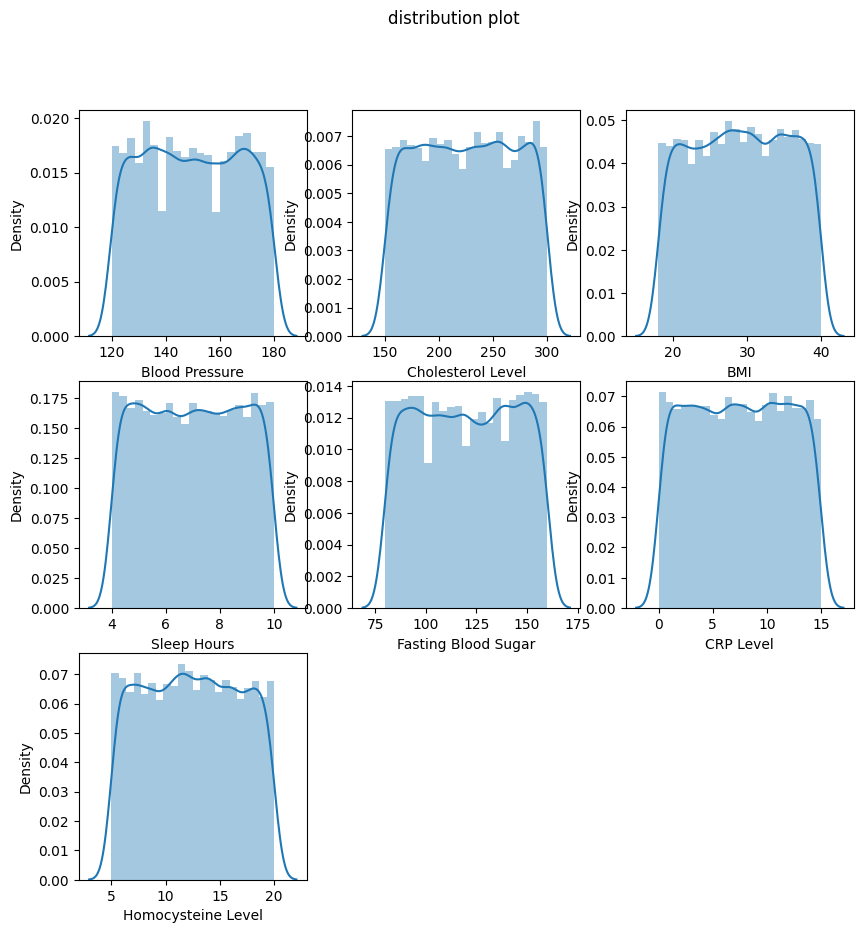

In [35]:
distribution = ['Blood Pressure', 'Cholesterol Level', 'BMI' ,  'Sleep Hours' ,'Fasting Blood Sugar','CRP Level', 'Homocysteine Level' ]

plt.figure(figsize=(10 , 10))
plt.suptitle('distribution plot')
for i in range(0 , len(distribution)):
    
    plt.subplot(3 , 3 , i+1)
    sns.distplot(df[distribution[i]])
    plt.xlabel(distribution[i])
plt.show()


## Find outlier treatment

In [36]:
df.head()

,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No


In [37]:
# drop Heart Disease Status because this columns is another type of target columns 

df.drop('Heart Disease Status' , axis=1 , inplace=True)

In [38]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption     9970 non-

In [39]:
# seprate nuerical and calegorical columns

num_col = [num for num in df.columns if df[num].dtype != 'str']
cat_col = [cat for cat in df.columns if df[cat].dtype == 'str']

In [40]:
num_col

['Age',
 'Blood Pressure',
 'Cholesterol Level',
 'BMI',
 'Sleep Hours',
 'Triglyceride Level',
 'Fasting Blood Sugar',
 'CRP Level',
 'Homocysteine Level']

In [41]:
cat_col

['Gender',
 'Exercise Habits',
 'Smoking',
 'Family Heart Disease',
 'Diabetes',
 'High Blood Pressure',
 'Low HDL Cholesterol',
 'High LDL Cholesterol',
 'Alcohol Consumption',
 'Stress Level',
 'Sugar Consumption']

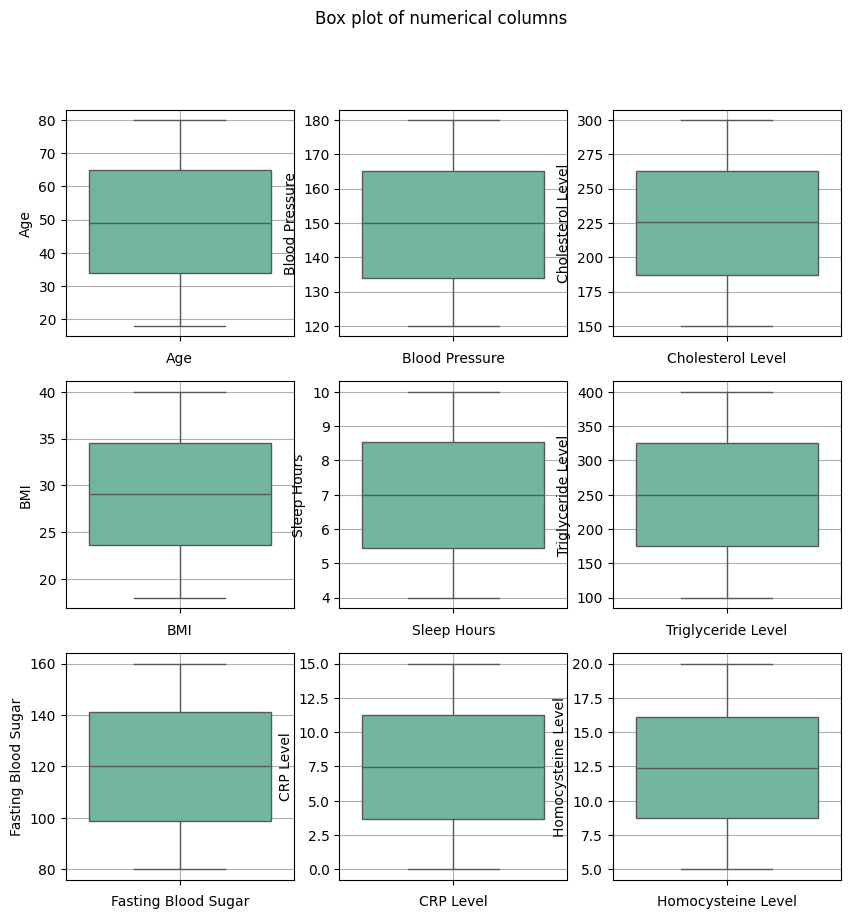

In [42]:
# box plot out of numerical columns 

plt.figure(figsize=(10 , 10))
plt.suptitle('Box plot of numerical columns')
for i in range(0 , len(num_col)):
    
    plt.subplot(3 , 3 , i+1)
    sns.boxplot(df[num_col[i]] , palette='Set2')
    plt.xlabel(num_col[i])
    plt.grid()
plt.show()


# No outliers present in the numerical columns

we can fill null valuse by mean

In [43]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
dtype: int64

In [44]:
for i in num_col:
    df[i] = df[i].fillna(df[i].mean())
    print(f"mean value of {i} is : {df[i].mean()}")


mean value of Age is : 49.29625915153946
mean value of Blood Pressure is : 149.75773970544034
mean value of Cholesterol Level is : 225.42557673019058
mean value of BMI is : 29.07726892751104
mean value of Sleep Hours is : 6.991329446342599
mean value of Triglyceride Level is : 250.734409464608
mean value of Fasting Blood Sugar is : 120.14221286831028
mean value of CRP Level is : 7.472200593944747
mean value of Homocysteine Level is : 12.45627088214965


In [45]:
df.isnull().sum()

Age                        0
Gender                    19
Blood Pressure             0
Cholesterol Level          0
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                        0
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours                0
Sugar Consumption         30
Triglyceride Level         0
Fasting Blood Sugar        0
CRP Level                  0
Homocysteine Level         0
dtype: int64

In [46]:
df.shape

(10000, 20)

## Alcohol Consumption - 
column has 2586 missing values that is 26% of the data if we fill it with mode the bias problem will be come heance take percentage of each class and fill.

In [47]:
dist = df['Alcohol Consumption'].value_counts(normalize=True)

miss_data = df['Alcohol Consumption'].isnull()

df.loc[miss_data, 'Alcohol Consumption'] = np.random.choice(
    dist.index,          # Medium/Low/High  
    size=miss_data.sum(),    # size of missing data
    p=dist.values            # probabilities to missing data
)

In [48]:
df['Alcohol Consumption'].isnull().sum()

np.int64(0)

In [49]:
# we can fill other categorical columns to mode
cat_col = [cat for cat in cat_col if cat != 'Alcohol Consumption']
cat_col

['Gender',
 'Exercise Habits',
 'Smoking',
 'Family Heart Disease',
 'Diabetes',
 'High Blood Pressure',
 'Low HDL Cholesterol',
 'High LDL Cholesterol',
 'Stress Level',
 'Sugar Consumption']

In [50]:
for i in cat_col:
    df[i] = df[i].fillna(df[i].mode()[0])
    

In [51]:
df.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
dtype: int64

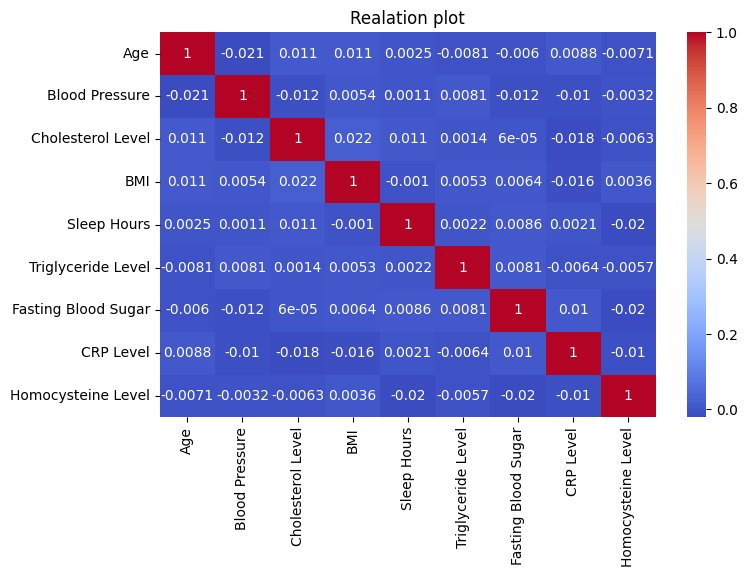

In [52]:
# plot correlation plot 

plt.figure(figsize=(8 , 5))
sns.heatmap(df.corr(numeric_only=True) , cmap='coolwarm' , annot=True)
plt.title('Realation plot')
plt.show()

we can clearly see the high correlation between the columns 

## Final Report

* In the dataset missing values and correlation 
* missing valuse should be fill with mean in numerical columns , by mode in categorical columns
* to create model we have to handle the coreelation
* in the dataset no outliers present
